# Introdução à Identificação de Sistemas

## Questão 1a

Text(0, 0.5, 'Temperatura de Entrada (K)')

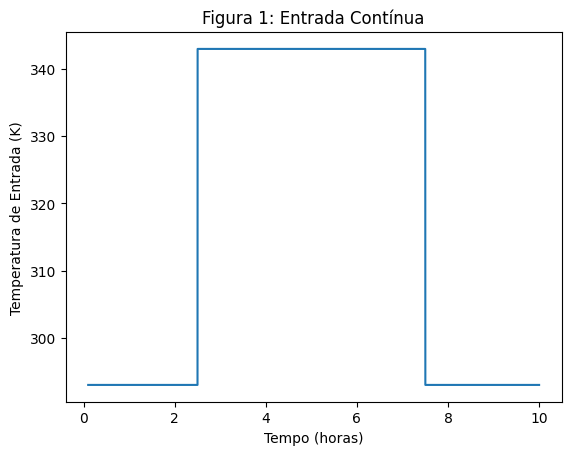

In [16]:
def u_cont(t):
    return 293 + 50 * (t >= 2.5) - 50 * (t >= 7.5)

t_end = 10

import numpy as np

t = np.linspace(0.1, t_end, int(1e6))
u_input_cont = [u_cont(t) for t in t]

import matplotlib.pyplot as plt

plt.plot(t, u_input_cont)
plt.title('Figura 1: Entrada Contínua')
plt.xlabel('Tempo (horas)')
plt.ylabel('Temperatura de Entrada (K)')

A entrada tem valor inicial $u_0=y_0=293$. Entre 2.5 horas e 7.5 horas após o início do experimento, $u=343$. Após 7.5 horas, $u=293$.

## Questão 1b

Text(0, 0.5, 'Temperatura (K)')

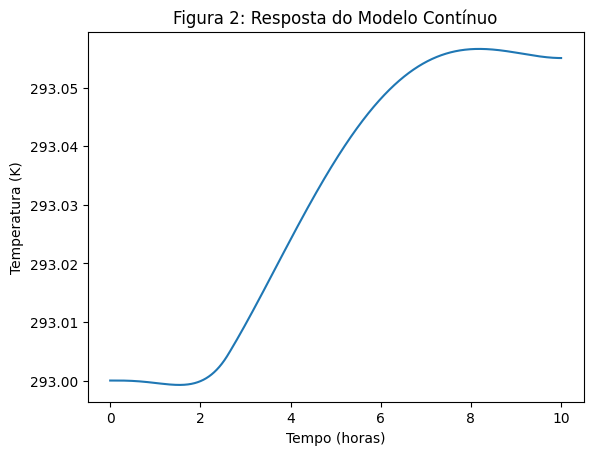

In [17]:
def model_cont(t, y):
    u = u_cont(t)
    dydt = 2.13e-12 * (u**4) - 2.41e-12 * (y**4) + 3.46e-10 * (y**3) - 2.63e-10 * (y**2) * u
    return dydt

from scipy.integrate import solve_ivp

def y_cont(t_end=t_end, y0=293):
    t_span = (0, t_end)
    t_eval = np.linspace(0, t_end, int(1e6))
    sol = solve_ivp(model_cont, t_span, [y0], t_eval=t_eval)
    return sol.t, sol.y.flatten()

t_cont, y_cont_values = y_cont()

plt.plot(t_cont, y_cont_values)
plt.title('Figura 2: Resposta do Modelo Contínuo')
plt.xlabel('Tempo (horas)')
plt.ylabel('Temperatura (K)')

A saída do sistema aumenta, linearmente, durante o pulso na entrada. Seu perfil indica uma característica integrativa com coeficiente baixo, já que a variação total na temperatura é pequena.

## Questão 2a

Text(0, 0.5, 'Temperatura de Entrada (K)')

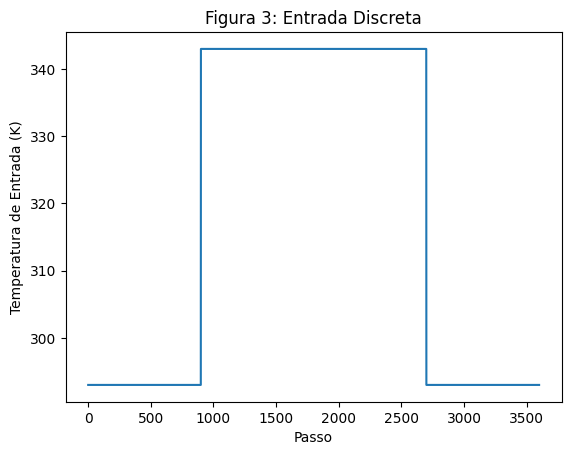

In [18]:
Ts = 10 / 3600

def u_disc(k, Ts=Ts):
    t = k * Ts
    return u_cont(t)

k_input = np.arange(0, t_end / Ts + 1)
u_input_disc = [u_disc(k) for k in k_input]

plt.plot(k_input, u_input_disc)
plt.title('Figura 3: Entrada Discreta')
plt.xlabel('Passo')
plt.ylabel('Temperatura de Entrada (K)')

## Questão 2b

Text(0, 0.5, 'Temperatura (K)')

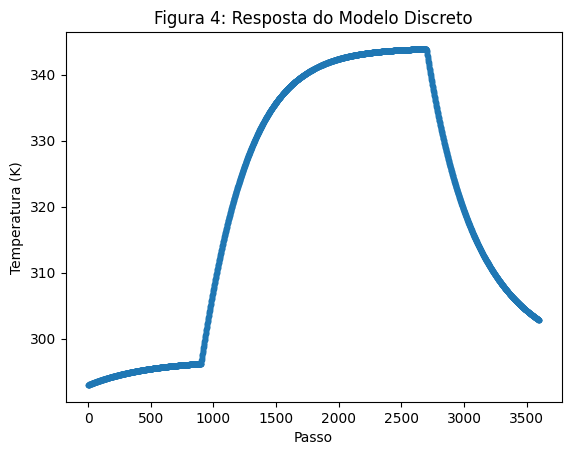

In [19]:
def y_disc(t_end=t_end, y0=293, Ts=Ts):
    step_count = int(t_end / Ts) + 1
    y = np.zeros(step_count)
    y[0] = y0

    for k in range(1, step_count):
        u_prev = u_disc(k - 1)
        y[k] = 3.27e-2 + 1.00 * y[k-1] - 8.51e-5 * u_prev - 1.98e-11 * y[k-1]**4 + 1.98e-11 * u_prev**4
    
    return y

y_disc_values = y_disc()

plt.plot(k_input, y_disc_values, '.')
plt.title('Figura 4: Resposta do Modelo Discreto')
plt.xlabel('Passo')
plt.ylabel('Temperatura (K)')

A saída deste sistema tem perfil de variação proporcional à diferença entre a temperatura e a entrada. As derivadas de maior módulo são observadas nos momentos em que a entrada sofre variação brusca. À medida que a temperatura se aproxima do valor na entrada, a variação é reduzida.

## Questão 2c

As saídas são muito diferentes. A princípio, representam sistemas distintos.

## Questão 3a

Sejam os sistemas

$$
\begin{gather}

5u(t)\frac{dy}{dt} \;+\; y(t) \;-\; 10u(t) \;=\; 0 \\
\tau\frac{dy}{dt} \;+\; y(t) \;-\; K\cdot{}u(t) \;=\; 0

\end{gather}
$$

**1** não é linear, porque há multiplicação entre sinais. **2** é linear, já que não há multiplicação entre sinais ou aplicação de funções não lineares sobre os sinais. Para conferir a linearidade do comportamento dos modelos em simulação, a igualdade $ f(u_1) + f(u_2) = f(u_1 + u_2) $ será avaliada para cada um.

Text(0.5, 0.98, 'Figura 5: Verificação de Linearidade')

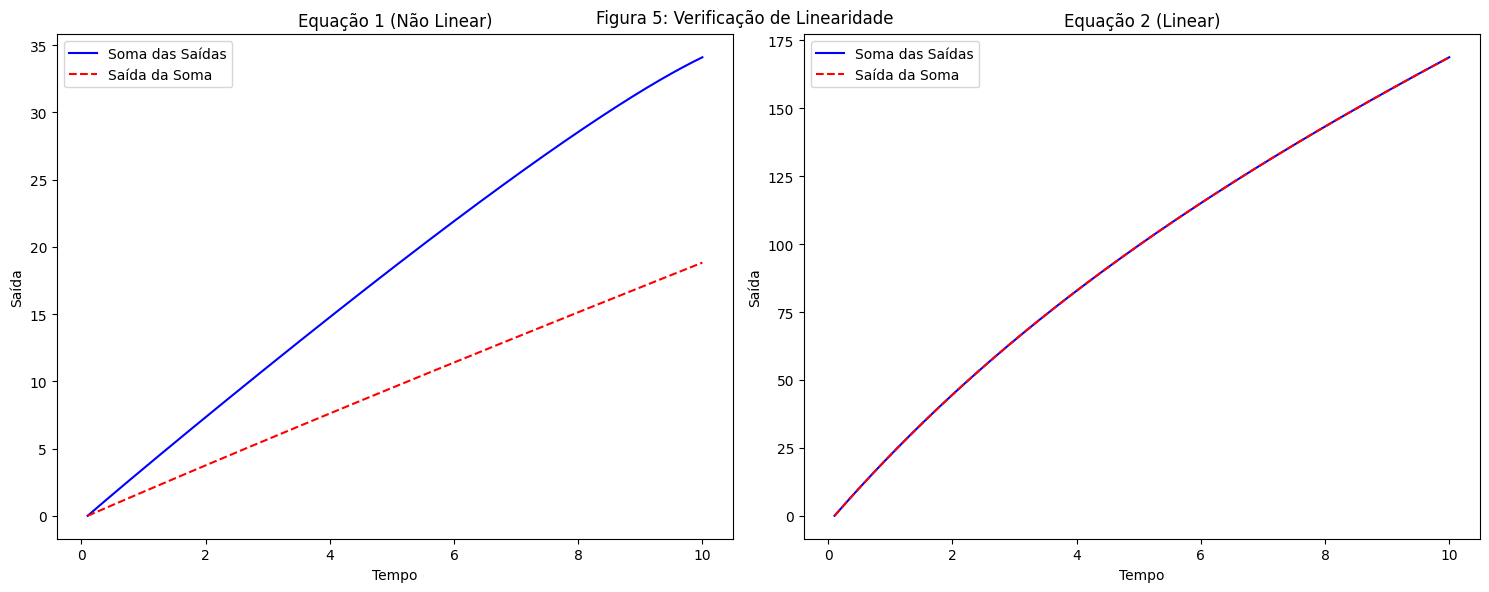

In [23]:
def equation_1(t, y, u_func):
    dydt = ( 10 * u_func(t) - y ) / ( 5 * u_func(t) )
    return dydt

def equation_2(t, y, u_func, tau, K):
    dydt = ( K * u_func(t) - y ) / tau
    return dydt

def u_1(t):
    return 2 * t + 1

def u_2(t):
    return 12 - t

tau = 5
K = 10

def sum_of_outputs(t, equation, args, u_1, u_2):
    t_span = (0.1, t[-1])
    
    def cond_1(t, y):
        return equation(t, y, u_1, *args)
    
    def cond_2(t, y):
        return equation(t, y, u_2, *args)
    
    sol_1 = solve_ivp(cond_1, t_span, [0], t_eval=t)
    sol_2 = solve_ivp(cond_2, t_span, [0], t_eval=t)

    return sol_1.t, sol_1.y + sol_2.y

def output_of_sums(t, equation, args, u_1, u_2):
    t_span = (0.1, t[-1])

    def u_combined(t):
        return u_1(t) + u_2(t)
    
    def cond(t, y):
        return equation(t, y, u_combined, *args)
    
    sol = solve_ivp(cond, t_span, [0], t_eval=t)

    return sol.t, sol.y

eq1_sumofout = sum_of_outputs(t, equation_1, [], u_1, u_2)
eq1_outofsum = output_of_sums(t, equation_1, [], u_1, u_2)

eq2_sumofout = sum_of_outputs(t, equation_2, [tau, K], u_1, u_2)
eq2_outofsum = output_of_sums(t, equation_2, [tau, K], u_1, u_2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(eq1_sumofout[0], eq1_sumofout[1].flatten(), 'b-', label='Soma das Saídas')
ax1.plot(eq1_outofsum[0], eq1_outofsum[1].flatten(), 'r--', label='Saída da Soma')
ax1.set_title('Equação 1 (Não Linear)')
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Saída')
ax1.legend()

ax2.plot(eq2_sumofout[0], eq2_sumofout[1].flatten(), 'b-', label='Soma das Saídas')
ax2.plot(eq2_outofsum[0], eq2_outofsum[1].flatten(), 'r--', label='Saída da Soma')
ax2.set_title('Equação 2 (Linear)')
ax2.set_xlabel('Tempo')
ax2.set_ylabel('Saída')
ax2.legend()

plt.tight_layout()
plt.suptitle('Figura 5: Verificação de Linearidade')


Para **1**, $ f(u_1) + f(u_2) \ne f(u_1 + u_2) $, comportamento não linear. Para **2**, $ f(u_1) + f(u_2) = f(u_1 + u_2) $, comportamento linear. Tais resultados condizem com a análise simbólica.